## Load Data
We load Brent, WTI and TTF Natural Gas prices for the Iran 2026 conflict 
window (Feb 21 – present). TTF data is sourced from Investing.com as EIA 
does not track European gas prices.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load master for Brent and WTI
master = pd.read_csv('../outputs/master_prices.csv', parse_dates=['date'])
# Actual Brent prices from event date onward
actual = master[master['date'] >= '2026-03-02'][['date', 'brent']].rename(columns={'brent': 'actual_price'})

# Slice Iran window
iran = master[master['date'] >= '2026-02-21'].copy().reset_index(drop=True)

# Load TTF gas data
ttf = pd.read_csv('../data/Dutch TTF Natural Gas Futures Historical Data.csv')
ttf = ttf[['Date', 'Price']].rename(columns={'Date': 'date', 'Price': 'ttf'})
ttf['date'] = pd.to_datetime(ttf['date'])
ttf = ttf.sort_values('date').reset_index(drop=True)

# Merge TTF into iran window
iran = iran.reset_index(drop=True)
iran = pd.merge(iran[['date', 'brent', 'wti', 'gas', 'name', 'type']], ttf, on='date', how='left')

print(iran)

         date   brent    wti    gas                   name type     ttf
0  2026-02-23   71.90  66.36  3.072                    NaN  NaN  31.834
1  2026-02-24   71.21  65.62  3.072                    NaN  NaN  30.891
2  2026-02-25   70.69  65.30  3.072                    NaN  NaN  31.050
3  2026-02-26   71.66  65.10  3.072                    NaN  NaN  32.224
4  2026-02-27   71.32  66.96  3.072                    NaN  NaN  31.959
5  2026-03-02   77.24  71.13  3.148  US-Israel war on Iran  war  44.506
6  2026-03-03   83.28  74.48  3.148                    NaN  NaN  54.290
7  2026-03-04   81.56  74.58  3.148                    NaN  NaN  48.767
8  2026-03-05   88.59  80.88  3.148                    NaN  NaN  50.731
9  2026-03-06   95.74  90.77  3.148                    NaN  NaN  53.385
10 2026-03-09   94.35  94.65  3.148                    NaN  NaN     NaN
11 2026-03-10   89.84  83.71  3.148                    NaN  NaN     NaN
12 2026-03-11   90.98  86.80  3.148                    NaN  NaN 

## Save Iran 2026 Daily Data
Export the Iran conflict price window to CSV. 

In [8]:
iran.to_csv('../outputs/iran_2026_daily.csv', index=False)
print("Saved! Shape:", iran.shape)

Saved! Shape: (16, 7)


## Build Iran Conflict Timeline
We manually construct a granular timeline of key conflict events to use 
as annotation markers on our charts. 

In [9]:
iran_events = pd.DataFrame([
    {'date': '2026-02-28', 'event': 'US-Israel strikes begin, Supreme Leader assassinated', 'category': 'military'},
    {'date': '2026-03-01', 'event': 'Tanker transits drop from 24/day to 4', 'category': 'supply'},
    {'date': '2026-03-02', 'event': 'VLCC freight rates hit all-time high of $423k/day', 'category': 'market'},
    {'date': '2026-03-03', 'event': 'QatarEnergy halts LNG production at Ras Laffan', 'category': 'supply'},
    {'date': '2026-03-04', 'event': 'NYT reports Iranian back-channel ceasefire talks', 'category': 'diplomatic'},
    {'date': '2026-03-05', 'event': 'South Korea warns LNG reserves critical (9 days remaining)', 'category': 'supply'},
    {'date': '2026-03-06', 'event': 'Brent peaks at $95.74 as Hormuz closure confirmed by Lloyd\'s. US grants India 30-day waiver to buy Russian oil', 'category': 'market'},
    {'date': '2026-03-07', 'event': 'US 5th Fleet repositions to escort corridor, limited tanker movement resumes', 'category': 'military'},
    {'date': '2026-03-08', 'event': 'G7 emergency meeting, strategic reserve releases coordinated', 'category': 'diplomatic'},
    {'date': '2026-03-09', 'event': 'Prices ease to $94.35 as partial Hormuz transit corridor opens. Trump announces sanctions on some oil producers will be lifted', 'category': 'diplomatic'},
    {'date': '2026-03-10', 'event': 'Brent swings wildly, briefly near $120, after Energy Secretary Wright falsely claims US Navy escorted tanker through Hormuz then deletes post', 'category': 'market'},
    {'date': '2026-03-11', 'event': 'IEA coordinates release of 400 million barrels from emergency reserves across 32 member states. Wave of ship attacks in Hormuz, at least 3 vessels hit', 'category': 'supply'},
    {'date': '2026-03-12', 'event': 'US Treasury formally lifts sanctions on Russian oil loaded before March 12, 30-day waiver through April 11', 'category': 'diplomatic'},
    {'date': '2026-03-13', 'event': 'Brent settles just above $100 as Iran\'s new Supreme Leader vows Hormuz will remain closed until war ends. Sanctions relief fails to calm markets', 'category': 'market'},
])

iran_events['date'] = pd.to_datetime(iran_events['date'])
iran_events = iran_events.sort_values('date').reset_index(drop=True)
iran_events.to_csv('../outputs/iran_events.csv', index=False)
print(iran_events)

         date                                              event    category
0  2026-02-28  US-Israel strikes begin, Supreme Leader assass...    military
1  2026-03-01              Tanker transits drop from 24/day to 4      supply
2  2026-03-02  VLCC freight rates hit all-time high of $423k/day      market
3  2026-03-03     QatarEnergy halts LNG production at Ras Laffan      supply
4  2026-03-04   NYT reports Iranian back-channel ceasefire talks  diplomatic
5  2026-03-05  South Korea warns LNG reserves critical (9 day...      supply
6  2026-03-06  Brent peaks at $95.74 as Hormuz closure confir...      market
7  2026-03-07  US 5th Fleet repositions to escort corridor, l...    military
8  2026-03-08  G7 emergency meeting, strategic reserve releas...  diplomatic
9  2026-03-09  Prices ease to $94.35 as partial Hormuz transi...  diplomatic
10 2026-03-10  Brent swings wildly, briefly near $120, after ...      market
11 2026-03-11  IEA coordinates release of 400 million barrels...      supply

## Calibrate Scenario Speeds from Historical Data
Rather than assuming arbitrary speed parameters, we calculate them from 
historical events with similar characteristics to each scenario. This 
grounds our projections in real observed price behaviour.

- **Scenario A (quick resolution):** Calibrated from 9/11 — prices recovered 
  within ~3 days, representing a fast-moving situation
- **Scenario B (prolonged disruption):** Calibrated from Libya 2011 — a slow 
  burning supply disruption that took 74 days to peak
- **Scenario C (escalation):** Calibrated from Ukraine 2022 — a fast geopolitical 
  shock that hit peak price in 12 days

In [10]:
# Load historical metrics
metrics = pd.read_csv('../outputs/event_metrics.csv', parse_dates=['date'])

# Extract days to peak for our calibration events
ukraine_days = metrics.loc[metrics['event'] == 'Ukraine invasion', 'days_to_peak'].values[0]
libya_days   = metrics.loc[metrics['event'] == 'Libya civil war', 'days_to_peak'].values[0]
nine11_days  = metrics.loc[metrics['event'] == '9/11 attacks', 'days_to_peak'].values[0]

# Back-calculate speed: at days_to_peak, curve should be ~95% of the way to target
# 0.95 = 1 - exp(-speed * days_to_peak)
# exp(-speed * days_to_peak) = 0.05
# speed = -ln(0.05) / days_to_peak

speed_c = -np.log(0.05) / ukraine_days
speed_b = -np.log(0.05) / libya_days
speed_a = -np.log(0.05) / nine11_days

print(f"Scenario A speed (9/11):     {speed_a:.4f} — peaks in ~{nine11_days} days")
print(f"Scenario B speed (Libya):    {speed_b:.4f} — peaks in ~{libya_days} days")
print(f"Scenario C speed (Ukraine):  {speed_c:.4f} — peaks in ~{ukraine_days} days")

Scenario A speed (9/11):     0.9986 — peaks in ~3 days
Scenario B speed (Libya):    0.0405 — peaks in ~74 days
Scenario C speed (Ukraine):  0.2496 — peaks in ~12 days


## Scenario Projections
We model three forward-looking price trajectories for Brent crude fanning out 
from the event date (March 2, 2026) at $77.24/barrel. Speeds are calibrated 
from historical events rather than assumed: Scenario A from 9/11 (3 days), 
Scenario B from Libya 2011 (74 days), Scenario C from Ukraine 2022 (12 days).

- Scenario A: Quick resolution — ceasefire within 2 weeks, prices retreat to ~$68
- Scenario B: Prolonged disruption — 4-8 weeks of Hormuz disruption, prices grind to ~$100
- Scenario C: Escalation — full closure 2+ months, Saudi infrastructure hit, prices spike to ~$145

**Update (March 9, 2026):** Actual price data has been added alongside the 
projections. Scenario A is already falsified — prices never retreated.

In [11]:
# Starting point
start_date = pd.Timestamp('2026-03-02')
current_price = 77.24
days = np.arange(0, 91)
dates = [start_date + pd.Timedelta(days=int(d)) for d in days]

# Scenario curves - exponential decay toward target price
def scenario_curve(start, target, days, speed=0.05):
    return start + (target - start) * (1 - np.exp(-speed * days))

scenario_a = scenario_curve(current_price, 68, days, speed=speed_a)
scenario_b = scenario_curve(current_price, 100, days, speed=speed_b)
scenario_c = scenario_curve(current_price, 145, days, speed=speed_c)

scenario_projections = pd.DataFrame({
    'date': dates,
    'Scenario A': scenario_a.round(2),
    'Scenario B': scenario_b.round(2),
    'Scenario C': scenario_c.round(2)
})

scenario_projections = scenario_projections.merge(actual, on='date', how='left')
scenario_projections['actual_price'] = scenario_projections['actual_price'].interpolate(method='linear', limit=2)
scenario_projections.to_csv('../outputs/scenario_projections.csv', index=False)
print(scenario_projections.head(10))

        date  Scenario A  Scenario B  Scenario C  actual_price
0 2026-03-02       77.24       77.24       77.24     77.240000
1 2026-03-03       71.40       78.14       92.21     83.280000
2 2026-03-04       69.25       79.01      103.87     81.560000
3 2026-03-05       68.46       79.84      112.96     88.590000
4 2026-03-06       68.17       80.64      120.04     95.740000
5 2026-03-07       68.06       81.41      125.55     95.276667
6 2026-03-08       68.02       82.15      129.85     94.813333
7 2026-03-09       68.01       82.86      133.20     94.350000
8 2026-03-10       68.00       83.54      135.80     89.840000
9 2026-03-11       68.00       84.19      137.84     90.980000


## Scenario Projection Chart
Three scenarios fan out from the March 2 event date at $77.24/barrel. 
The gold line shows actual Brent prices through March 9, 2026, 
plotted against the three projections.

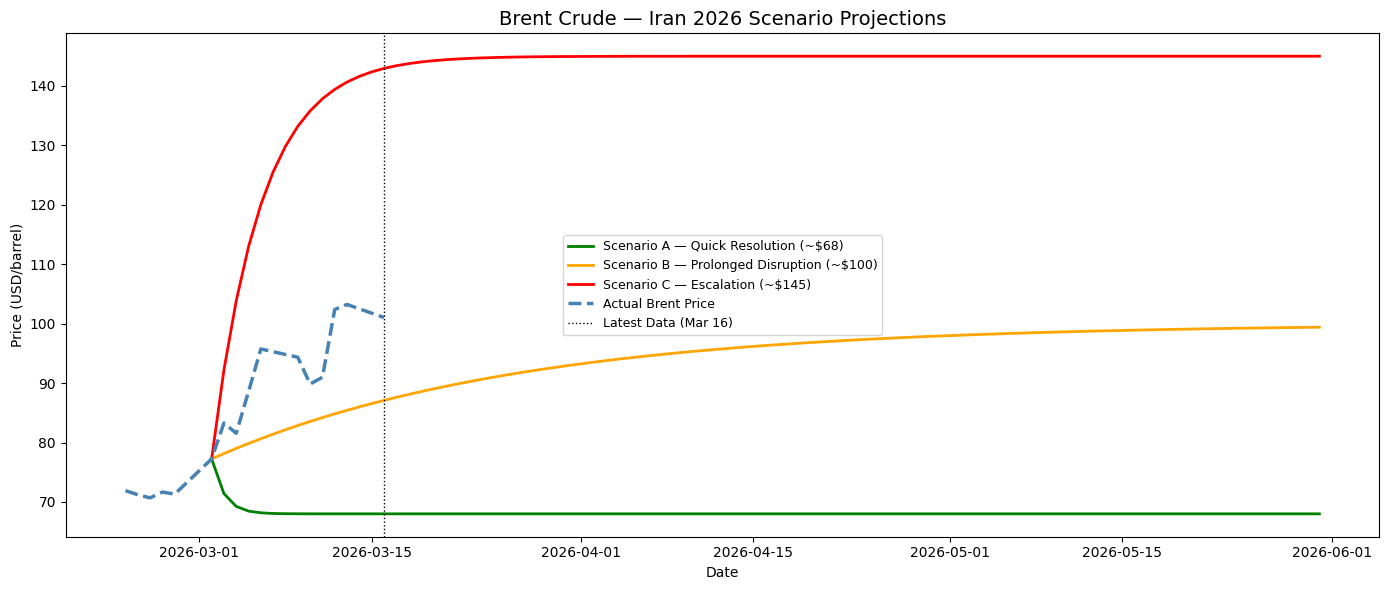

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(scenario_projections['date'], scenario_projections['Scenario A'], color='green', linewidth=2, label='Scenario A — Quick Resolution (~$68)')
ax.plot(scenario_projections['date'], scenario_projections['Scenario B'], color='orange', linewidth=2, label='Scenario B — Prolonged Disruption (~$100)')
ax.plot(scenario_projections['date'], scenario_projections['Scenario C'], color='red', linewidth=2, label='Scenario C — Escalation (~$145)')

# Plot actual price so far
ax.plot(iran['date'], iran['brent'], color='steelblue', linewidth=2.5, linestyle='--', label='Actual Brent Price')

# Mark today
ax.axvline(pd.Timestamp('2026-03-16'), color='black', linestyle=':', linewidth=1, label='Latest Data (Mar 16)')

ax.set_title('Brent Crude — Iran 2026 Scenario Projections', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/iran_scenario_chart.png', dpi=150)
plt.show()

## Scenario Chart Analysis

As of March 16, 2026 the actual price data tells a clear story:

- **Scenario A (green):** Already falsified. Prices never retreated toward $68. 
  Quick resolution is off the table.
- **Scenario B (orange):** Calibrated from Libya 2011, a slow burning 
  supply disruption grinding toward $100 over ~74 days. Prices crossed 
  $100 on March 16, entering Prolonged Disruption territory for the first time.
- **Scenario C (red):** Calibrated from Ukraine 2022, an aggressive escalation 
  toward $145. The Day 4 peak of $95.74 briefly approached this trajectory 
  before pulling back, but the March 16 print of $101.04 shows prices 
  climbing again.

Prices pulled back from the $95.74 peak to $89.84 on March 10, then climbed 
steadily through the week to close at $101.04 on March 16. The partial 
Hormuz transit corridor has not been enough to calm markets. The new Supreme 
Leader has vowed to keep the Strait closed until the war ends.

## Country Vulnerability Analysis
We rank key countries by their exposure to the Strait of Hormuz disruption 
across three dimensions: oil exposure, LNG exposure, and availability of 
pipeline alternatives. This feeds directly into the Tableau world heatmap.

Scoring: High = 3, Medium = 2, Low = 1. Total vulnerability score is the 
sum of oil and LNG exposure minus pipeline alternatives.

In [14]:
vulnerability = pd.DataFrame([
    {'country': 'South Korea', 'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'No pipeline alternatives. Confirmed 9 days LNG reserves remaining as of March 5'},
    {'country': 'Japan',       'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'No pipeline alternatives. QatarEnergy Ras Laffan shutdown directly impacts supply'},
    {'country': 'Pakistan',    'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'Highly dependent, no alternatives. Forex reserves too low to absorb price shock'},
    {'country': 'Taiwan',      'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'No domestic production, no pipeline alternatives'},
    {'country': 'Singapore',   'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'Entirely import dependent, major refining hub'},
    {'country': 'India',       'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Can pivot to Russian supply but Ras Laffan shutdown affects LNG contracts'},
    {'country': 'China',       'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Can pivot to Russian supply. Strategic reserves provide short term buffer'},
    {'country': 'Thailand',    'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 1, 'notes': 'High oil dependency, limited alternatives'},
    {'country': 'Philippines', 'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 1, 'notes': 'Island nation, no pipeline alternatives'},
    {'country': 'Germany',     'oil_exposure': 2, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Partial pipeline alternatives via Norway. G7 reserve release partially offsets'},
    {'country': 'France',      'oil_exposure': 2, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Nuclear buffered but still oil dependent. G7 reserve release partially offsets'},
    {'country': 'Italy',       'oil_exposure': 2, 'lng_exposure': 3, 'pipeline_alternatives': 2, 'notes': 'High LNG dependency, some pipeline alternatives'},
    {'country': 'Spain',       'oil_exposure': 2, 'lng_exposure': 3, 'pipeline_alternatives': 2, 'notes': 'Major LNG importer'},
    {'country': 'United Kingdom', 'oil_exposure': 1, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'North Sea buffer but significant Qatari LNG dependency. G7 reserve release partially offsets'},
    {'country': 'Turkey',      'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Strategic location, some pipeline access'},
    {'country': 'Brazil',      'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 2, 'notes': 'Major domestic producer'},
    {'country': 'Australia',   'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 2, 'notes': 'Major LNG exporter, self sufficient'},
    {'country': 'USA',         'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Buffered by domestic production. Coordinating G7 strategic reserve releases'},
    {'country': 'Canada',      'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major domestic producer'},
    {'country': 'Russia',      'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major exporter, not exposed'},
    {'country': 'Saudi Arabia', 'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major exporter'},
    {'country': 'Iraq',        'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major exporter'},
])

vulnerability['vulnerability_score'] = (
    vulnerability['oil_exposure'] + 
    vulnerability['lng_exposure'] - 
    vulnerability['pipeline_alternatives']
)

vulnerability = vulnerability.sort_values('vulnerability_score', ascending=False).reset_index(drop=True)

vulnerability.to_csv('../outputs/country_vulnerability.csv', index=False)
print(vulnerability[['country', 'oil_exposure', 'lng_exposure', 'pipeline_alternatives', 'vulnerability_score']])

           country  oil_exposure  lng_exposure  pipeline_alternatives  \
0      South Korea             3             3                      1   
1            Japan             3             3                      1   
2         Pakistan             3             3                      1   
3           Taiwan             3             3                      1   
4        Singapore             3             3                      1   
5         Thailand             3             2                      1   
6      Philippines             3             2                      1   
7            India             3             2                      2   
8            China             3             2                      2   
9            Italy             2             3                      2   
10           Spain             2             3                      2   
11          Turkey             3             2                      2   
12          France             2             2     

## Vulnerability Score Analysis
Countries are ranked by a composite vulnerability score (oil exposure + 
LNG exposure - pipeline alternatives). Higher scores indicate greater 
exposure to a prolonged Strait of Hormuz disruption.

**Most vulnerable (score 5):** South Korea, Japan, Pakistan, Taiwan and 
Singapore — all heavily import-dependent with no pipeline alternatives. 
South Korea publicly warned it had only 9 days of LNG reserves remaining.

**High vulnerability (score 4):** Thailand and the Philippines — high oil 
dependency with no pipeline alternatives, though slightly less LNG exposed 
than the score 5 group.

**Moderately vulnerable (score 3):** China, India, Italy, Spain and Turkey — 
meaningful exposure but partially buffered. China and India can pivot to 
Russian overland supply; Italy and Spain are major LNG importers with some 
pipeline access.

**Low vulnerability (score 2):** France and Germany — European pipeline 
networks and in France's case nuclear generation provide meaningful buffers.

**Minimal vulnerability (score 1):** United Kingdom — North Sea domestic 
production cushions the blow.

**Not exposed (score 0):** Brazil and Australia — both have significant 
domestic production and are net energy exporters.

**Negative score (-1):** USA, Canada, Russia, Saudi Arabia and Iraq — all 
major producers or exporters who are largely insulated from or actively 
benefit from a Hormuz disruption.